In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
ridership = pd.read_csv("ridership_by_station.csv")
ridership.head()

,station_id,stationname,date,daytype,rides
0,40350,UIC-Halsted,01/01/2001,U,273
1,41130,Halsted-Orange,01/01/2001,U,306
2,40760,Granville,01/01/2001,U,"1,059"
3,40070,Jackson/Dearborn,01/01/2001,U,649
4,40090,Damen-Brown,01/01/2001,U,411


In [5]:
ridership['date'] = pd.to_datetime(ridership['date'])
ridership['daytype'] = ridership['daytype'].astype('category')
ridership['rides'] = ridership['rides'].str.replace(',', '').astype(int)
ridership.info()

<class 'pandas.DataFrame'>
RangeIndex: 1298399 entries, 0 to 1298398
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   station_id   1298399 non-null  int64         
 1   stationname  1298399 non-null  str           
 2   date         1298399 non-null  datetime64[us]
 3   daytype      1298399 non-null  category      
 4   rides        1298399 non-null  int64         
dtypes: category(1), datetime64[us](1), int64(2), str(1)
memory usage: 40.9 MB


In [6]:
ridership.head()

,station_id,stationname,date,daytype,rides
0,40350,UIC-Halsted,2001-01-01,U,273
1,41130,Halsted-Orange,2001-01-01,U,306
2,40760,Granville,2001-01-01,U,1059
3,40070,Jackson/Dearborn,2001-01-01,U,649
4,40090,Damen-Brown,2001-01-01,U,411


In [7]:
station_info = pd.read_csv("system_info.csv")
station_info.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,Location
0,30162,W,18th (54th/Cermak-bound),18th,18th (Pink Line),40830,True,False,False,False,False,False,False,True,False,"(41.857908, -87.669147)"
1,30161,E,18th (Loop-bound),18th,18th (Pink Line),40830,True,False,False,False,False,False,False,True,False,"(41.857908, -87.669147)"
2,30022,N,35th/Archer (Loop-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,False,False,False,False,True,"(41.829353, -87.680622)"
3,30023,S,35th/Archer (Midway-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,False,False,False,False,True,"(41.829353, -87.680622)"
4,30213,N,35-Bronzeville-IIT (Harlem-bound),35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),41120,True,False,False,True,False,False,False,False,False,"(41.831677, -87.625826)"


In [8]:
station_info['DIRECTION_ID'] = station_info['DIRECTION_ID'].astype('category')
station_info['MAP_ID'] = station_info['MAP_ID'].astype(int)
for col in station_info.select_dtypes(include=['bool']).columns:
    station_info[col] = station_info[col].astype(int)

station_info[['latitude', 'longitude']] = station_info['Location'].str.strip().str.strip('()').str.split(', ', expand=True)
station_info['latitude'] = pd.to_numeric(station_info['latitude'].str.strip())
station_info['longitude'] = pd.to_numeric(station_info['longitude'].str.strip())
station_info = station_info[['STATION_NAME', 'DIRECTION_ID', 'MAP_ID', 'ADA', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude']]
station_info.head()

,STATION_NAME,DIRECTION_ID,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,latitude,longitude
0,18th,W,40830,1,0,0,0,0,0,0,1,0,41.857908,-87.669147
1,18th,E,40830,1,0,0,0,0,0,0,1,0,41.857908,-87.669147
2,35th/Archer,N,40120,1,0,0,0,0,0,0,0,1,41.829353,-87.680622
3,35th/Archer,S,40120,1,0,0,0,0,0,0,0,1,41.829353,-87.680622
4,35th-Bronzeville-IIT,N,41120,1,0,0,1,0,0,0,0,0,41.831677,-87.625826


In [9]:
#Identify which stations have conflicting ADA status (i.e. part of station or certain lines are ADA compliant while others aren't)
grouped_ada = station_info.groupby('MAP_ID')['ADA'].apply(lambda x: x.unique())
conflicting_stations = grouped_ada[grouped_ada.apply(lambda x: 0 in x and 1 in x)].index.tolist()

print("STATION_NAMEs with conflicting ADA values:", conflicting_stations)

STATION_NAMEs with conflicting ADA values: []


In [11]:
agg_dict = {
    'STATION_NAME': 'first',
    'latitude': 'first',
    'longitude': 'first',
    'DIRECTION_ID': lambda x: tuple(x.unique()),
    'ADA': 'max',
    'RED': 'max',
    'BLUE': 'max',
    'G': 'max',
    'BRN': 'max',
    'P': 'max',
    'Y': 'max',
    'Pnk': 'max',
    'O': 'max'
}

si_aggregated = station_info.groupby('MAP_ID').agg(agg_dict).reset_index()
si_aggregated.head()

,MAP_ID,STATION_NAME,latitude,longitude,DIRECTION_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O
0,40010,Austin,41.870851,-87.776812,"(W, E)",0,0,1,0,0,0,0,0,0
1,40020,Harlem/Lake,41.886848,-87.803176,"(W, E)",1,0,0,1,0,0,0,0,0
2,40030,Pulaski,41.885412,-87.725404,"(W, E)",1,0,0,1,0,0,0,0,0
3,40040,Quincy/Wells,41.878723,-87.633740,"(N, S)",1,0,0,0,1,1,0,1,1
4,40050,Davis,42.047710,-87.683543,"(N, S)",1,0,0,0,0,1,0,0,0


In [12]:
#Turn direction into a dummy variable
direction_dummies = si_aggregated['DIRECTION_ID'].apply(lambda x: '|'.join(map(str, x))).str.get_dummies()
si_aggregated = si_aggregated.join(direction_dummies).drop(columns=['DIRECTION_ID'])
si_aggregated['N/S'] = si_aggregated['N'] | si_aggregated['S']
si_aggregated['E/W'] = si_aggregated['E'] | si_aggregated['W']
si_aggregated = si_aggregated.drop(columns=['N', 'S', 'E', 'W'])
si_aggregated.head()

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0


In [13]:
station_ridership = pd.merge(ridership, si_aggregated, left_on='station_id', right_on='MAP_ID', how='left')
display(station_ridership)

,station_id,stationname,date,daytype,rides,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,40350,UIC-Halsted,2001-01-01,U,273,40350.0,UIC-Halsted,41.875474,-87.649707,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,41130,Halsted-Orange,2001-01-01,U,306,41130.0,Halsted,41.846780,-87.648088,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,40760,Granville,2001-01-01,U,1059,40760.0,Granville,41.993664,-87.659202,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,40070,Jackson/Dearborn,2001-01-01,U,649,40070.0,Jackson,41.878183,-87.629296,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,40090,Damen-Brown,2001-01-01,U,411,40090.0,Damen,41.966286,-87.678639,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298394,41670,Conservatory,2025-11-30,U,307,41670.0,Conservatory,41.884904,-87.716523,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298395,41680,Oakton-Skokie,2025-11-30,U,162,41680.0,Oakton-Skokie,42.026243,-87.747221,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1298396,41690,Cermak-McCormick Place,2025-11-30,U,715,41690.0,Cermak-McCormick Place,41.853115,-87.626402,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1298397,41700,Washington/Wabash,2025-11-30,U,2704,41700.0,Washington/Wabash,41.883220,-87.626189,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0


In [14]:
start_date = pd.to_datetime('2000-01-01')
station_ridership['days_since_2000'] = (station_ridership['date'] - start_date).dt.days

#Calculate month (as integer)
station_ridership['month'] = station_ridership['date'].dt.month

#Calculate year
station_ridership['year'] = station_ridership['date'].dt.year

#Define a function to get the season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

#Apply the function to get the season column
station_ridership['season'] = station_ridership['month'].apply(get_season)

#Display the first few rows with the new columns
print(station_ridership[['date', 'days_since_2000', 'season', 'month', 'year']].head())

        date  days_since_2000  season  month  year
0 2001-01-01              366  Winter      1  2001
1 2001-01-01              366  Winter      1  2001
2 2001-01-01              366  Winter      1  2001
3 2001-01-01              366  Winter      1  2001
4 2001-01-01              366  Winter      1  2001


In [15]:
#Identify rows with missing latitude or longitude
missing_coords_df = station_ridership[station_ridership['latitude'].isnull() | station_ridership['longitude'].isnull()]

#Get unique station names with missing coordinates, excluding NaN values
unique_stations_missing_coords = missing_coords_df['stationname'].dropna().unique()

if len(unique_stations_missing_coords) == 0:
    print("No stations found with missing latitude or longitude values.")
else:
    print("Stations with missing latitude or longitude values and their date range:")
    for station_name in unique_stations_missing_coords:
        # Filter for the current station and missing coordinates using 'stationname'
        station_missing_data = missing_coords_df[missing_coords_df['stationname'] == station_name]

        # Get the first and last date for this station's missing coordinates
        first_date = station_missing_data['date'].min()
        last_date = station_missing_data['date'].max()

        print(f"{station_name}, {first_date.strftime('%Y-%m-%d')} through {last_date.strftime('%Y-%m-%d')}")

Stations with missing latitude or longitude values and their date range:
Randolph/Wabash, 2001-01-01 through 2019-01-31
Madison/Wabash, 2001-01-01 through 2018-01-01
Washington/State, 2001-01-01 through 2009-01-31
Homan, 2001-07-01 through 2001-07-31


<Axes: >

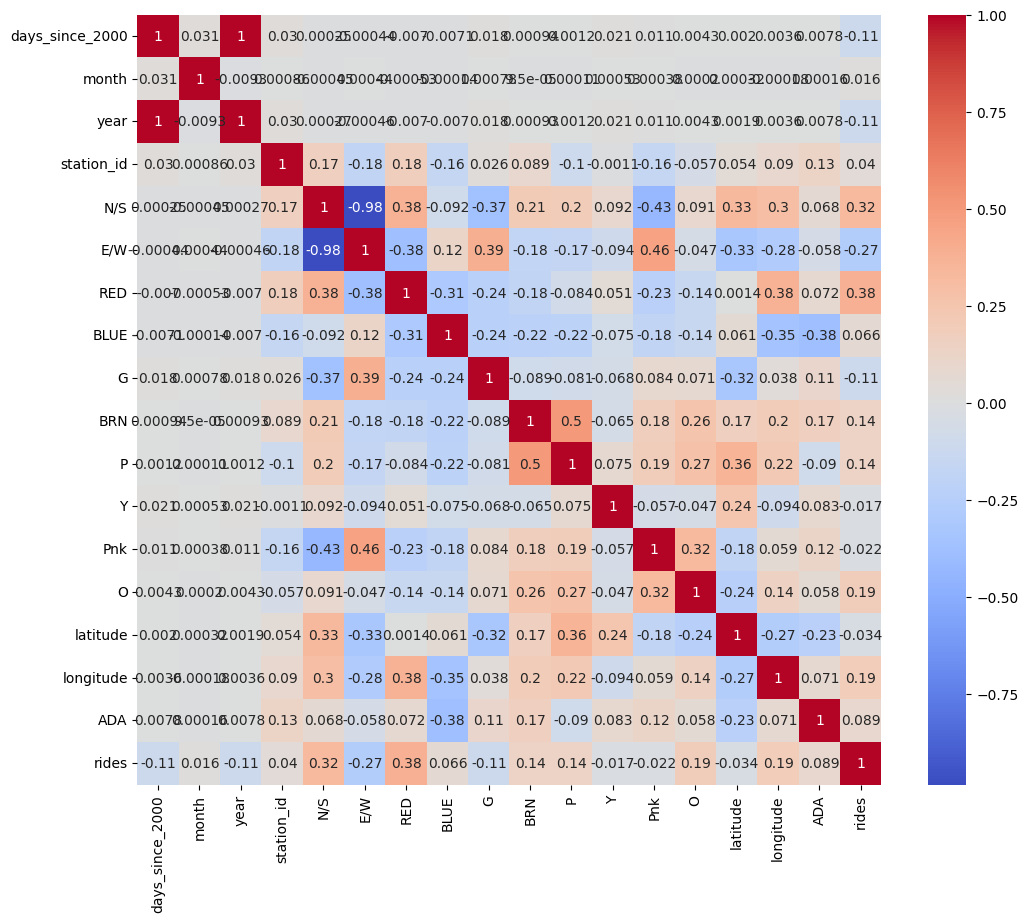

In [16]:
columns_for_splom = ['days_since_2000', 'month', 'year', 'station_id', 'N/S', 'E/W', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude', 'ADA', 'rides']

#See correlations
plt.figure(figsize=(12,10))
sns.heatmap(station_ridership[columns_for_splom].corr(), annot=True, cmap='coolwarm')

In [ ]:
sns.pairplot(station_ridership, x_vars=['days_since_2000', 'month', 'year', 'station_id', 'N/S', 'E/W', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude', 'ADA'], y_vars=['rides'])
plt.show()

: 

: 

In [ ]:
sns.pairplot(station_ridership[['days_since_2000', 'month', 'year', 'station_id', 'latitude', 'longitude', 'rides']])
plt.show()

: 